# Libraries

In [2]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
    
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import glob
import math
from tqdm import tqdm
from PIL import Image
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.models as models
import torchvision.datasets as datasets
import torchvision.transforms as transforms

from image_show import *

np.set_printoptions(precision=2)
np.random.seed(1234)

## Dataset

In [4]:
# Dataset paths
DATA_DIR= "plant-seedlings-classification/"
trn_dir= f'{DATA_DIR}train'
vld_dir= f'{DATA_DIR}valid'
tst_dir= f'{DATA_DIR}test'

In [6]:
os.listdir(DATA_DIR)

['sample_submission.csv', 'test', 'train', 'valid']

In [8]:
os.listdir(trn_dir)

['Black-grass',
 'Charlock',
 'Cleavers',
 'Common Chickweed',
 'Common wheat',
 'Fat Hen',
 'Loose Silky-bent',
 'Maize',
 'Scentless Mayweed',
 'Shepherds Purse',
 'Small-flowered Cranesbill',
 'Sugar beet']

In [10]:
# Check a few image paths
trn_fnames= glob.glob(f'{trn_dir}/*/*.png')
trn_fnames[:5]

['plant-seedlings-classification/train\\Black-grass\\0050f38b3.png',
 'plant-seedlings-classification/train\\Black-grass\\0183fdf68.png',
 'plant-seedlings-classification/train\\Black-grass\\0260cffa8.png',
 'plant-seedlings-classification/train\\Black-grass\\05eedce4d.png',
 'plant-seedlings-classification/train\\Black-grass\\075d004bc.png']

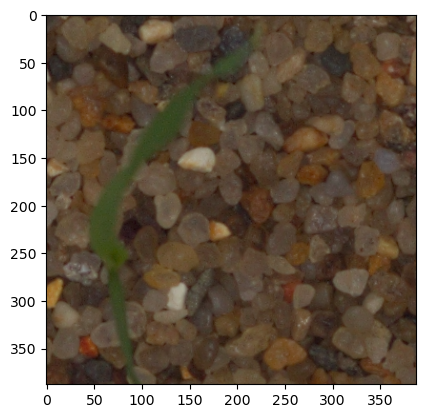

In [12]:
# Display one example image
img= plt.imread(trn_fnames[1])
plt.imshow(img)
plt.show()

In [14]:
batch_size= 16
sz= 224

### Transformations

In [11]:
# Define image transformations
tfms = transforms.Compose([
    transforms.Resize((sz, sz)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Create datasets
trn_ds= datasets.ImageFolder(trn_dir, tfms)
val_ds= datasets.ImageFolder(vld_dir, tfms)

In [12]:
len(trn_ds), len(val_ds)

(3801, 950)

In [13]:
trn_ds.classes

['Black-grass',
 'Charlock',
 'Cleavers',
 'Common Chickweed',
 'Common wheat',
 'Fat Hen',
 'Loose Silky-bent',
 'Maize',
 'Scentless Mayweed',
 'Shepherds Purse',
 'Small-flowered Cranesbill',
 'Sugar beet']

In [14]:
trn_ds.class_to_idx

{'Black-grass': 0,
 'Charlock': 1,
 'Cleavers': 2,
 'Common Chickweed': 3,
 'Common wheat': 4,
 'Fat Hen': 5,
 'Loose Silky-bent': 6,
 'Maize': 7,
 'Scentless Mayweed': 8,
 'Shepherds Purse': 9,
 'Small-flowered Cranesbill': 10,
 'Sugar beet': 11}

## DataLoders

In [16]:
# Create dataloaders
trn_dl= torch.utils.data.DataLoader(trn_ds, batch_size= batch_size, shuffle= True, num_workers=4)
val_dl= torch.utils.data.DataLoader(val_ds, batch_size= batch_size, shuffle= True, num_workers=4)

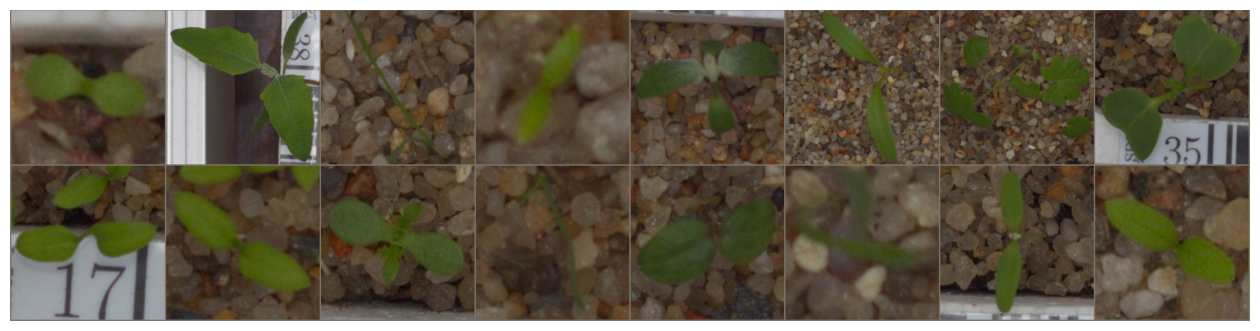

In [17]:
# Display a batch of training images
inputs, tarets= next(iter(trn_dl))
out= torchvision.utils.make_grid(inputs)
plt.figure(figsize=(16, 12))
imshow(out)
plt.show()

## Model: CNN

In [35]:
# Define a simple 2-layer CNN architecture

class SimpleCnn(nn.Module):
    def __init__(self):
        super(SimpleCnn, self).__init__()

        self.Conv1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
            )
        self.Conv2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Fully connected layer for 12-class classification
        self.fc= nn.Linear(56*56*32, 12) 

    def forward(self, x):
        out= self.Conv1(x)
        out= self.Conv2(out)
        out= out.view(out.size(0), -1) # Flatten feature maps
        out= self.fc(out)
        return out

In [37]:
# Create model
model= SimpleCnn()
model

SimpleCnn(
  (Conv1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (Conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=100352, out_features=12, bias=True)
)

## Loss function and optimizer

In [40]:
critetion= nn.CrossEntropyLoss()
optimizer= optim.SGD(model.parameters(), lr= 0.002, momentum=0.9)
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Train

In [24]:
# Train Step

num_epochs= 10
losses= []

for epoch in range(num_epochs):
    for i, (inputs,targets) in enumerate(trn_dl):
        inputs, targets= inputs.to(device), targets.to(device)
        # Forward
        outputs= model(inputs)
        
        # Loss
        loss = critetion(outputs, targets)
        losses.append(loss.item())

        # # Backward pass and update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print loss every 50 steps
        if (i+1) % 50 ==0:
            print('Epoch[%2d/%2d], Step[%3d/%3d], Loss: %.4f'
                 %(epoch +1, num_epochs, i+1, len(trn_ds)//batch_size, loss.item()))

Epoch[ 1/10], Step[ 50/237], Loss: 1.8908
Epoch[ 1/10], Step[100/237], Loss: 1.9386
Epoch[ 1/10], Step[150/237], Loss: 1.9073
Epoch[ 1/10], Step[200/237], Loss: 1.6270
Epoch[ 2/10], Step[ 50/237], Loss: 1.7003
Epoch[ 2/10], Step[100/237], Loss: 0.8984
Epoch[ 2/10], Step[150/237], Loss: 0.8257
Epoch[ 2/10], Step[200/237], Loss: 1.3419
Epoch[ 3/10], Step[ 50/237], Loss: 1.3152
Epoch[ 3/10], Step[100/237], Loss: 0.9435
Epoch[ 3/10], Step[150/237], Loss: 0.6019
Epoch[ 3/10], Step[200/237], Loss: 1.0182
Epoch[ 4/10], Step[ 50/237], Loss: 0.7257
Epoch[ 4/10], Step[100/237], Loss: 0.2633
Epoch[ 4/10], Step[150/237], Loss: 0.7197
Epoch[ 4/10], Step[200/237], Loss: 0.3447
Epoch[ 5/10], Step[ 50/237], Loss: 0.9115
Epoch[ 5/10], Step[100/237], Loss: 0.3142
Epoch[ 5/10], Step[150/237], Loss: 0.3968
Epoch[ 5/10], Step[200/237], Loss: 0.7764
Epoch[ 6/10], Step[ 50/237], Loss: 0.3619
Epoch[ 6/10], Step[100/237], Loss: 0.3059
Epoch[ 6/10], Step[150/237], Loss: 0.3621
Epoch[ 6/10], Step[200/237], Loss:

#### Accuracy

In [26]:
# Evaluation function
def validate(model, data_loader, device):
    model.eval()
    corrects= 0

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs, targets= inputs.to(device), targets.to(device)
            outputs= model(inputs)
            _, preds= torch.max(outputs, 1)
            corrects += (preds == targets.data).sum()
    print('accuracy: {:.2f}'.format(100. * corrects / len(data_loader.dataset)))

In [27]:
validate(model, val_dl, device)

accuracy: 67.37


In [28]:
validate(model, trn_dl, device)

accuracy: 98.08


#### Confusion matrix

In [40]:
# Evaluation function
def validate(model, data_loader, device):
    model.eval()
    result = []
    y = []
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs, targets= inputs.to(device), targets.to(device)
            outputs= model(inputs)
            _, preds= torch.max(outputs, 1)
            result += [preds.cpu().numpy()]
            y += [targets.cpu().numpy()]
    result = np.concatenate(result)
    y = np.concatenate(y)
    return result, y

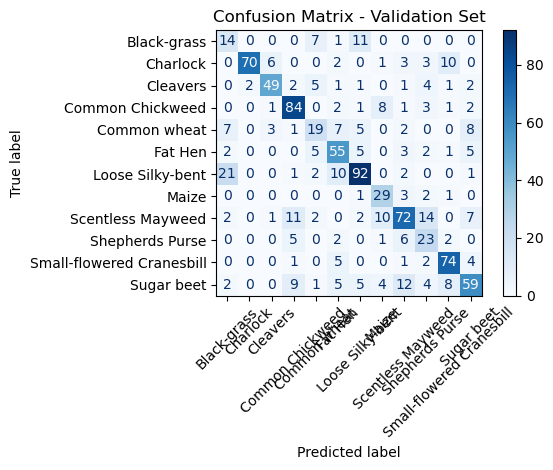

In [48]:
y_true, y_pred = validate(model, val_dl, device)
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=trn_ds.classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Validation Set")
plt.tight_layout()
plt.show()

# Data Augmentation

In [21]:
train_tfms = transforms.Compose([
    transforms.Resize((sz, sz)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

valid_tfms = transforms.Compose([
    transforms.Resize((sz, sz)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds= datasets.ImageFolder(trn_dir, train_tfms)
valid_ds= datasets.ImageFolder(vld_dir, valid_tfms)

train_dl= torch.utils.data.DataLoader(train_ds, batch_size= batch_size, shuffle=True, num_workers=4)
valid_dl= torch.utils.data.DataLoader(valid_ds, batch_size= batch_size, shuffle=True, num_workers=4)



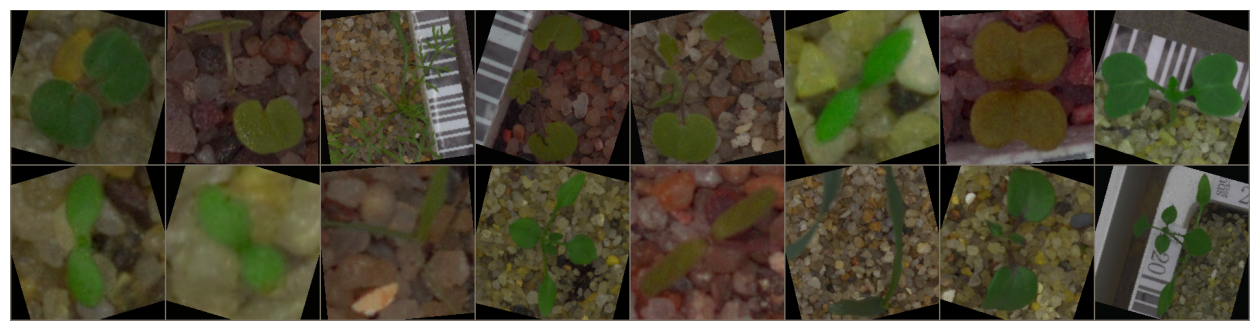

In [23]:
inputs, targets = next(iter(train_dl))
img= torchvision.utils.make_grid(inputs, padding=2)
plt.figure(figsize=(16, 12))
imshow(img)
plt.show()

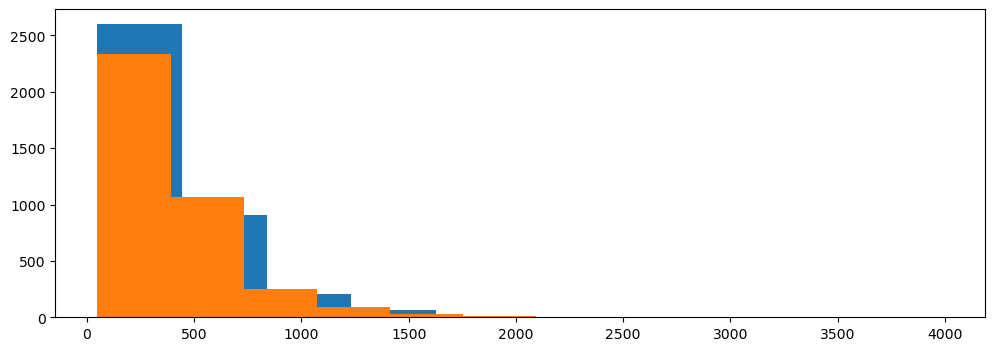

In [31]:
fnames = glob.glob(f'{trn_dir}/*/*.png')
sizes = [Image.open(f).size for f in fnames]
hs, ws = list(zip(*sizes))

plt.figure(figsize=(12, 4))
plt.hist(hs)
plt.hist(ws);
plt.show()

In [50]:
# Train Step

num_epochs= 10
losses= []

for epoch in range(num_epochs):
    print('Epoch {}/{}'.format(epoch + 1, num_epochs))
    print('-' * 10)
    for i, (inputs,targets) in enumerate(train_dl):
        inputs, targets= inputs.to(device), targets.to(device)
        # Forward
        outputs= model(inputs)
        
        # Loss
        loss = critetion(outputs, targets)
        losses.append(loss.item())

        # # Backward pass and update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print loss every 50 steps
        if (i+1) % 50 ==0:
            print('Step[%3d/%3d], Loss: %.4f'
                 %( i+1, len(train_ds)//batch_size, loss.item()))
           

Epoch 1/10
----------
Step[ 50/237], Loss: 1.3447
Step[100/237], Loss: 2.0377
Step[150/237], Loss: 1.6622
Step[200/237], Loss: 1.6642
Epoch 2/10
----------
Step[ 50/237], Loss: 1.3822
Step[100/237], Loss: 1.3572
Step[150/237], Loss: 1.1610
Step[200/237], Loss: 1.4441
Epoch 3/10
----------
Step[ 50/237], Loss: 1.5917
Step[100/237], Loss: 1.5673
Step[150/237], Loss: 1.5417
Step[200/237], Loss: 1.4495
Epoch 4/10
----------
Step[ 50/237], Loss: 1.0174
Step[100/237], Loss: 1.6520
Step[150/237], Loss: 1.6329
Step[200/237], Loss: 1.6332
Epoch 5/10
----------
Step[ 50/237], Loss: 1.1860
Step[100/237], Loss: 0.9480
Step[150/237], Loss: 0.8191
Step[200/237], Loss: 1.3673
Epoch 6/10
----------
Step[ 50/237], Loss: 1.1277
Step[100/237], Loss: 1.0208
Step[150/237], Loss: 1.5701
Step[200/237], Loss: 1.0694
Epoch 7/10
----------
Step[ 50/237], Loss: 0.8984
Step[100/237], Loss: 1.6155
Step[150/237], Loss: 0.8494
Step[200/237], Loss: 0.9056
Epoch 8/10
----------
Step[ 50/237], Loss: 0.7115
Step[100/237

In [57]:
# Evaluation function
def validate(model, data_loader, device):
    model.eval()
    corrects= 0

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs, targets= inputs.to(device), targets.to(device)
            outputs= model(inputs)
            _, preds= torch.max(outputs, 1)
            corrects += (preds == targets.data).sum()
    print('accuracy: {:.2f}'.format(100. * corrects / len(data_loader.dataset)))

In [59]:
validate(model, valid_dl, device)

accuracy: 68.63


In [60]:
validate(model, train_dl, device)

accuracy: 67.30
